# Tutorial 3: Solutions to Exercises 3.1 & 3.2

![Status](https://img.shields.io/static/v1.svg?label=Status&message=Open&color=blue)


**Open notebook on:** 
[![View filled on Github](https://img.shields.io/static/v1.svg?logo=github&label=Repo&message=View%20On%20Github&color=lightgrey)](https://github.com/clandolt/mlcysec_notebooks/blob/main/source/tutorial_notebooks/tutorial3_2_evading_ml_ids/tutorial3_2_evading_ml_ids.ipynb)
[![Open filled In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/clandolt/mlcysec_notebooks/blob/main/source/tutorial_notebooks/tutorial3_2_evading_ml_ids/tutorial3_2_evading_ml_ids.ipynb)   
**Author:** Christoph R. Landolt

This notebook provides the solutions for the exercises corresponding to Tutorials 3.1 and 3.2.

## Solutions for Tutorial 3.1: Getting started with GANs

### Exercise 1: Experimenting with Architectural Changes

Training with High-Capacity Generator on cpu...
Epoch [0/10000] | Loss D: 1.0652 | Loss G: 0.6828
Epoch [1000/10000] | Loss D: 1.5301 | Loss G: 0.6518
Epoch [2000/10000] | Loss D: 1.3694 | Loss G: 0.7004
Epoch [3000/10000] | Loss D: 1.4054 | Loss G: 0.6789
Epoch [4000/10000] | Loss D: 1.5464 | Loss G: 0.5368
Epoch [5000/10000] | Loss D: 1.4390 | Loss G: 0.6900
Epoch [6000/10000] | Loss D: 1.3789 | Loss G: 0.6107
Epoch [7000/10000] | Loss D: 1.3932 | Loss G: 0.6328
Epoch [8000/10000] | Loss D: 1.3683 | Loss G: 0.8075
Epoch [9000/10000] | Loss D: 1.4297 | Loss G: 0.6360


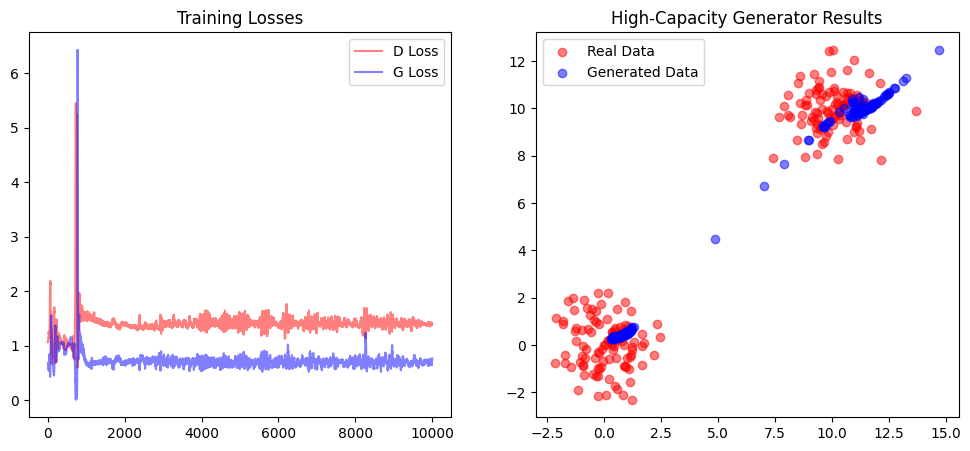

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. Define the Models ---

class HighCapacityGenerator(nn.Module):
    def __init__(self, input_dim=10, output_dim=2):
        super(HighCapacityGenerator, self).__init__()
        # Enhanced architecture: Adding an extra hidden layer and increasing width
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        return self.fc(x)

class Discriminator(nn.Module):
    def __init__(self, input_dim=2):
        super(Discriminator, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 50),
            nn.ReLU(),
            nn.Linear(50, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.fc(x)

# --- 2. Utility Functions ---

def generate_real_data(batch_size=64, mean1=0.0, mean2=10.0, std=1.0):
    half_batch = batch_size // 2
    data1 = np.random.normal(mean1, std, (half_batch, 2))
    data2 = np.random.normal(mean2, std, (batch_size - half_batch, 2))
    combined_data = np.vstack([data1, data2])
    return torch.tensor(combined_data, dtype=torch.float32).to(device)

def generate_noise(batch_size=64, noise_dim=10):
    return torch.randn(batch_size, noise_dim).to(device)

# --- 3. Initialization ---

noise_dim = 10
generator = HighCapacityGenerator(input_dim=noise_dim).to(device)
discriminator = Discriminator().to(device)

criterion = nn.BCELoss()
optimizer_g = optim.Adam(generator.parameters(), lr=0.001)
optimizer_d = optim.Adam(discriminator.parameters(), lr=0.001)

# Training parameters
num_epochs = 10000
batch_size = 64
losses_d = []
losses_g = []

# --- 4. Training Loop ---

print(f"Training with High-Capacity Generator on {device}...")

for epoch in range(num_epochs):
    # --- Step A: Train Discriminator ---
    optimizer_d.zero_grad()
    
    # Real data labels = 1, Fake data labels = 0
    real_data = generate_real_data(batch_size)
    real_labels = torch.ones(batch_size, 1).to(device)
    
    noise = generate_noise(batch_size, noise_dim)
    fake_data = generator(noise).detach() # Detach to avoid updating Generator
    fake_labels = torch.zeros(batch_size, 1).to(device)
    
    # D Loss
    out_real = discriminator(real_data)
    loss_d_real = criterion(out_real, real_labels)
    
    out_fake = discriminator(fake_data)
    loss_d_fake = criterion(out_fake, fake_labels)
    
    loss_d = loss_d_real + loss_d_fake
    loss_d.backward()
    optimizer_d.step()
    
    # --- Step B: Train Generator ---
    optimizer_g.zero_grad()
    
    noise = generate_noise(batch_size, noise_dim)
    fake_data = generator(noise)
    
    # G wants D to think fake data is real (label = 1)
    out_fake_for_g = discriminator(fake_data)
    loss_g = criterion(out_fake_for_g, real_labels)
    
    loss_g.backward()
    optimizer_g.step()
    
    # Save statistics
    losses_d.append(loss_d.item())
    losses_g.append(loss_g.item())

    if epoch % 1000 == 0:
        print(f"Epoch [{epoch}/{num_epochs}] | Loss D: {loss_d.item():.4f} | Loss G: {loss_g.item():.4f}")

# --- 5. Visualization ---

# Plot Losses
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(losses_d, label='D Loss', color='red', alpha=0.5)
plt.plot(losses_g, label='G Loss', color='blue', alpha=0.5)
plt.title("Training Losses")
plt.legend()

# Plot Generated Data vs Real Data
plt.subplot(1, 2, 2)
generator.eval()
with torch.no_grad():
    test_noise = generate_noise(200, noise_dim)
    generated = generator(test_noise).cpu().numpy()
    real = generate_real_data(200).cpu().numpy()

plt.scatter(real[:, 0], real[:, 1], c='red', label='Real Data', alpha=0.5)
plt.scatter(generated[:, 0], generated[:, 1], c='blue', label='Generated Data', alpha=0.5)
plt.title("High-Capacity Generator Results")
plt.legend()
plt.show()

Training with High-Capacity Generator AND Discriminator on cpu...
Epoch [0/10000] | Loss D: 1.3148 | Loss G: 0.7258
Epoch [1000/10000] | Loss D: 1.4623 | Loss G: 2.0059
Epoch [2000/10000] | Loss D: 0.8321 | Loss G: 1.1079
Epoch [3000/10000] | Loss D: 1.0891 | Loss G: 1.1807
Epoch [4000/10000] | Loss D: 0.9487 | Loss G: 1.2151
Epoch [5000/10000] | Loss D: 0.9483 | Loss G: 1.0017
Epoch [6000/10000] | Loss D: 0.9471 | Loss G: 1.0720
Epoch [7000/10000] | Loss D: 0.9419 | Loss G: 1.1445
Epoch [8000/10000] | Loss D: 0.9538 | Loss G: 1.1737
Epoch [9000/10000] | Loss D: 0.8072 | Loss G: 3.0626


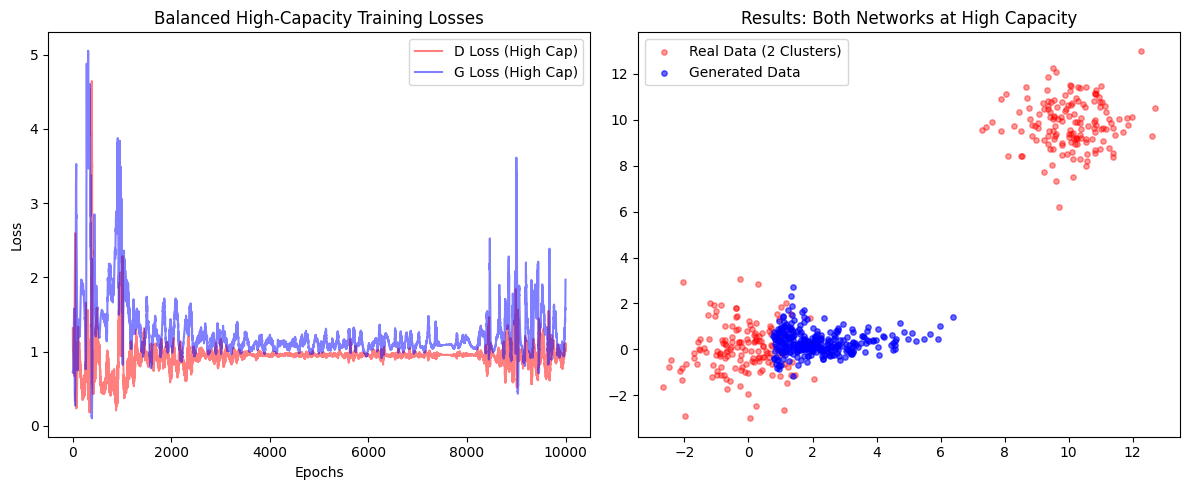

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. Define High-Capacity Models ---

class HighCapacityGenerator(nn.Module):
    def __init__(self, input_dim=10, output_dim=2):
        super(HighCapacityGenerator, self).__init__()
        # Architecture: 10 -> 128 -> 128 -> 2
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        return self.fc(x)

class HighCapacityDiscriminator(nn.Module):
    def __init__(self, input_dim=2):
        super(HighCapacityDiscriminator, self).__init__()
        # Architecture: 2 -> 128 -> 128 -> 1
        # Increased capacity to match the Generator
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.fc(x)

# --- 2. Utility Functions ---

def generate_real_data(batch_size=64, mean1=0.0, mean2=10.0, std=1.0):
    half_batch = batch_size // 2
    data1 = np.random.normal(mean1, std, (half_batch, 2))
    data2 = np.random.normal(mean2, std, (batch_size - half_batch, 2))
    combined_data = np.vstack([data1, data2])
    return torch.tensor(combined_data, dtype=torch.float32).to(device)

def generate_noise(batch_size=64, noise_dim=10):
    return torch.randn(batch_size, noise_dim).to(device)

# --- 3. Initialization ---

noise_dim = 10
generator = HighCapacityGenerator(input_dim=noise_dim).to(device)
discriminator = HighCapacityDiscriminator().to(device)

criterion = nn.BCELoss()
optimizer_g = optim.Adam(generator.parameters(), lr=0.001)
optimizer_d = optim.Adam(discriminator.parameters(), lr=0.001)

# Training parameters
num_epochs = 10000
batch_size = 64
losses_d = []
losses_g = []

# --- 4. Training Loop ---

print(f"Training with High-Capacity Generator AND Discriminator on {device}...")

for epoch in range(num_epochs):
    # --- Step A: Train Discriminator ---
    optimizer_d.zero_grad()
    
    real_data = generate_real_data(batch_size)
    real_labels = torch.ones(batch_size, 1).to(device)
    
    noise = generate_noise(batch_size, noise_dim)
    fake_data = generator(noise).detach() 
    fake_labels = torch.zeros(batch_size, 1).to(device)
    
    # Forward passes
    out_real = discriminator(real_data)
    out_fake = discriminator(fake_data)
    
    loss_d = criterion(out_real, real_labels) + criterion(out_fake, fake_labels)
    loss_d.backward()
    optimizer_d.step()
    
    # --- Step B: Train Generator ---
    optimizer_g.zero_grad()
    
    noise = generate_noise(batch_size, noise_dim)
    fake_data = generator(noise)
    
    # Try to fool the high-capacity discriminator
    out_fake_for_g = discriminator(fake_data)
    loss_g = criterion(out_fake_for_g, real_labels)
    
    loss_g.backward()
    optimizer_g.step()
    
    losses_d.append(loss_d.item())
    losses_g.append(loss_g.item())

    if epoch % 1000 == 0:
        print(f"Epoch [{epoch}/{num_epochs}] | Loss D: {loss_d.item():.4f} | Loss G: {loss_g.item():.4f}")

# --- 5. Visualization ---

plt.figure(figsize=(12, 5))

# Plot Losses
plt.subplot(1, 2, 1)
plt.plot(losses_d, label='D Loss (High Cap)', color='red', alpha=0.5)
plt.plot(losses_g, label='G Loss (High Cap)', color='blue', alpha=0.5)
plt.title("Balanced High-Capacity Training Losses")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Plot Results
plt.subplot(1, 2, 2)
generator.eval()
with torch.no_grad():
    test_noise = generate_noise(300, noise_dim)
    generated = generator(test_noise).cpu().numpy()
    real = generate_real_data(300).cpu().numpy()

plt.scatter(real[:, 0], real[:, 1], c='red', label='Real Data (2 Clusters)', alpha=0.4, s=15)
plt.scatter(generated[:, 0], generated[:, 1], c='blue', label='Generated Data', alpha=0.6, s=15)
plt.title("Results: Both Networks at High Capacity")
plt.legend()
plt.tight_layout()
plt.show()

Experiment 1: Powerful Generator vs. Weak Discriminator...
Experiment 2: Weak Generator vs. Powerful Discriminator...


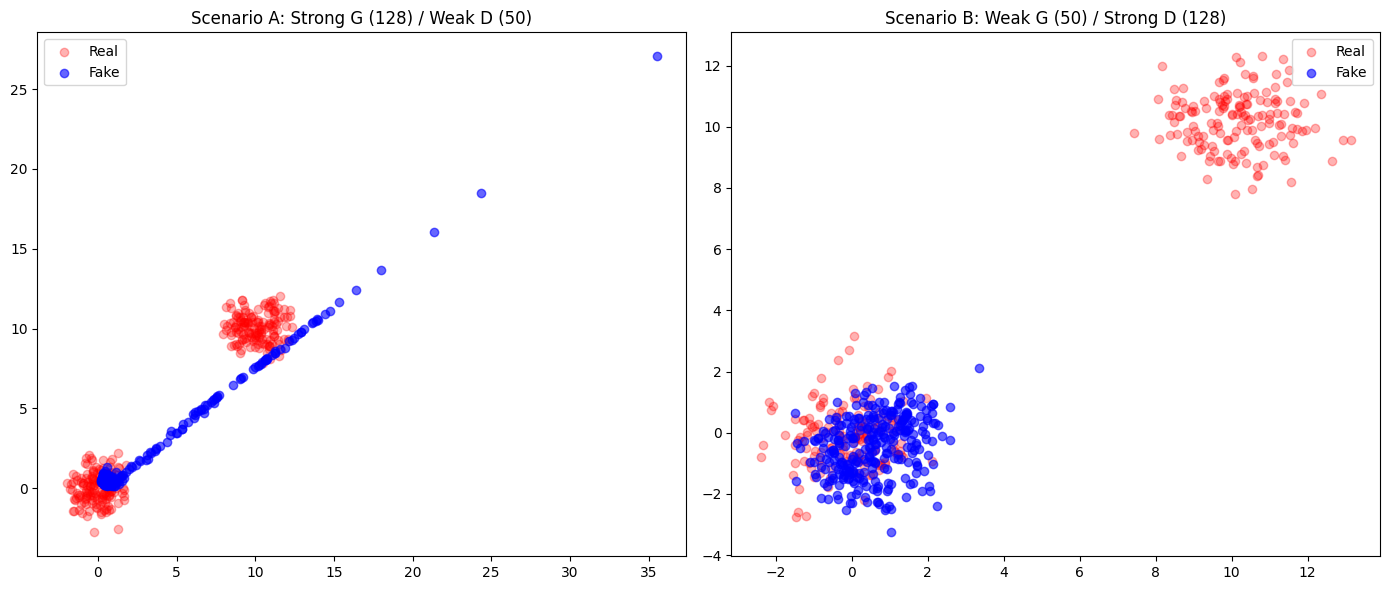

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. Define Architecture Variants ---

class Generator(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        # hidden_dim=50 for original, 128 for high-capacity
        self.fc = nn.Sequential(
            nn.Linear(10, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU() if hidden_dim==128 else nn.Identity(),
            nn.Linear(hidden_dim, 2)
        )
    def forward(self, x): return self.fc(x)

class Discriminator(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        # hidden_dim=50 for original, 128 for high-capacity
        self.fc = nn.Sequential(
            nn.Linear(2, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU() if hidden_dim==128 else nn.Identity(),
            nn.Linear(hidden_dim, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.fc(x)

# --- 2. Training Function ---

def train_gan(gen, disc, title, epochs=5000):
    criterion = nn.BCELoss()
    opt_g = optim.Adam(gen.parameters(), lr=0.001)
    opt_d = optim.Adam(disc.parameters(), lr=0.001)
    
    for epoch in range(epochs):
        # Train Discriminator
        opt_d.zero_grad()
        real = generate_real_data(64)
        fake = gen(generate_noise(64)).detach()
        loss_d = criterion(disc(real), torch.ones(64, 1).to(device)) + \
                 criterion(disc(fake), torch.zeros(64, 1).to(device))
        loss_d.backward()
        opt_d.step()

        # Train Generator
        opt_g.zero_grad()
        fake = gen(generate_noise(64))
        loss_g = criterion(disc(fake), torch.ones(64, 1).to(device))
        loss_g.backward()
        opt_g.step()
    
    return gen

# --- 3. Execution of Experiments ---

print("Experiment 1: Powerful Generator vs. Weak Discriminator...")
# High-cap Gen (128) + Low-cap Disc (50)
gen_1 = train_gan(Generator(128).to(device), Discriminator(50).to(device), "G > D")

print("Experiment 2: Weak Generator vs. Powerful Discriminator...")
# Low-cap Gen (50) + High-cap Disc (128)
gen_2 = train_gan(Generator(50).to(device), Discriminator(128).to(device), "D > G")

# --- 4. Visualization ---

plt.figure(figsize=(14, 6))

def plot_result(gen, subplot_idx, title):
    plt.subplot(1, 2, subplot_idx)
    gen.eval()
    with torch.no_grad():
        fake = gen(generate_noise(300)).cpu().numpy()
        real = generate_real_data(300).cpu().numpy()
    plt.scatter(real[:, 0], real[:, 1], c='red', alpha=0.3, label='Real')
    plt.scatter(fake[:, 0], fake[:, 1], c='blue', alpha=0.6, label='Fake')
    plt.title(title)
    plt.legend()

plot_result(gen_1, 1, "Scenario A: Strong G (128) / Weak D (50)")
plot_result(gen_2, 2, "Scenario B: Weak G (50) / Strong D (128)")
plt.tight_layout()
plt.show()

### Solutions: Exercise 1 Follow-up Questions

#### 1) Observation of Final Generated Data and Loss Curves
* **High-Capacity Generator / Low-Capacity Discriminator**: The generator has enough capacity to model both data modes, but because the discriminator is weak, it may not provide a sharp enough signal to force the generator to cover both clusters accurately. The loss curves often show the generator "winning" easily, potentially leading to **mode collapse** where it only covers one cluster.
* **Low-Capacity Generator / High-Capacity Discriminator**: The discriminator becomes too powerful for the generator to fool. This often results in a **"vanishing gradient"** problem where the generator’s loss becomes very high and stays flat because it cannot find any way to improve against the expert discriminator. The resulting data plot typically shows poor coverage of the real data distribution.
* **Balanced High-Capacity (Both 128 units)**: The loss curves show intense oscillations as both networks improve together. The final data plot shows the best attempt at covering both clusters, as both agents are matched in their ability to learn the complex multimodal distribution.

#### 2) Best Combination for Covering Both Data Modes
The **balanced high-capacity combination** (where both the Generator and Discriminator have 128-unit hidden layers) produces the best results. This setup allows the generator to capture the complexity of the two distinct clusters (modes) while the discriminator is strong enough to provide the necessary feedback to ensure the generator doesn't just settle for one "easy" cluster.

#### 3) Impact of Imbalanced Power and the "Delicate Balancing Act"
* **What happens**: When one network is significantly more powerful, the competitive nature of the GAN breaks down.
    * If the **Discriminator is too strong**, the Generator receives no useful gradient information to learn from and essentially gets "stuck".
    * If the **Generator is too strong**, it easily finds a single point that fools the weak Discriminator and stops exploring other parts of the data distribution (**mode collapse**).
* **The "Delicate Balancing Act"**: This relates to the game-theoretic foundation of GANs, where the goal is to reach a **Nash equilibrium**. Training only succeeds if both players are matched; if the competition isn't fair, one side dominates, the minimax game ends prematurely, and the generator never learns to replicate the true diversity of the real data distribution.

### Exercise 2: Implementing the Wasserstein GAN (WGAN)

## Solutions for Tutorial 3.2: Evading ML-based IDS

### Exercise 1: Attack Success vs. Perturbation Strength

### Exercise 2: Compare Models

---

[![Star our repository](https://img.shields.io/static/v1.svg?logo=star&label=⭐&message=Star%20Our%20Repository&color=yellow)](https://github.com/clandolt/mlcysec_notebooks/)  If you found this tutorial helpful, please **⭐ star our repository** to show your support.   
[![Ask questions](https://img.shields.io/static/v1.svg?logo=star&label=❔&message=Ask%20Questions&color=9cf)](https://github.com/clandolt/mlcysec_notebooks/issues)  For any **questions**, **typos**, or **bugs**, kindly open an issue on GitHub — we appreciate your feedback!

---